In [21]:
print("Hello, NewsLens AI!")

Hello, NewsLens AI!


In [22]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)

2.3.3
2.2.6


In [23]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [24]:
NEWS_COLUMNS = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities",
]

BEHAVIOR_COLUMNS = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions",
]

In [25]:
DATA_DIR = Path("../data/raw/MINDsmall")

news = pd.read_csv(
    DATA_DIR / "news.tsv",
    sep="\t",
    names=NEWS_COLUMNS,
)

behaviors = pd.read_csv(
    DATA_DIR / "behaviors.tsv",
    sep="\t",
    names=BEHAVIOR_COLUMNS,
)

In [26]:
print("News shape:", news.shape)
print("Behaviors shape:", behaviors.shape)

News shape: (51282, 8)
Behaviors shape: (156965, 5)


In [27]:
news.head()

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [28]:
behaviors.head()

,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [29]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   news_id            51282 non-null  object
 1   category           51282 non-null  object
 2   subcategory        51282 non-null  object
 3   title              51282 non-null  object
 4   abstract           48616 non-null  object
 5   url                51282 non-null  object
 6   title_entities     51279 non-null  object
 7   abstract_entities  51278 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


In [30]:
behaviors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156965 entries, 0 to 156964
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   impression_id  156965 non-null  int64 
 1   user_id        156965 non-null  object
 2   time           156965 non-null  object
 3   history        153727 non-null  object
 4   impressions    156965 non-null  object
dtypes: int64(1), object(4)
memory usage: 6.0+ MB


In [31]:
news["category"].value_counts()

category
news             15774
sports           14510
finance           3107
foodanddrink      2551
lifestyle         2479
travel            2350
video             2068
weather           2048
health            1885
autos             1639
tv                 889
music              769
movies             606
entertainment      587
kids                17
middleeast           2
northamerica         1
Name: count, dtype: int64

In [32]:
news["subcategory"].nunique()

264

In [33]:
news["news_id"].nunique()

51282

In [34]:
behaviors["user_id"].nunique()

50000

In [35]:
news.shape

(51282, 8)

In [36]:
behaviors.shape

(156965, 5)

In [37]:
print("=" * 50)
print("MIND Dataset Summary")
print("=" * 50)

print(f"News articles: {len(news):,}")
print(f"User sessions: {len(behaviors):,}")
print(f"Unique users: {behaviors['user_id'].nunique():,}")
print(f"Categories: {news['category'].nunique()}")
print(f"Subcategories: {news['subcategory'].nunique()}")

MIND Dataset Summary
News articles: 51,282
User sessions: 156,965
Unique users: 50,000
Categories: 17
Subcategories: 264


In [38]:
category_counts = news["category"].value_counts()

category_counts

category
news             15774
sports           14510
finance           3107
foodanddrink      2551
lifestyle         2479
travel            2350
video             2068
weather           2048
health            1885
autos             1639
tv                 889
music              769
movies             606
entertainment      587
kids                17
middleeast           2
northamerica         1
Name: count, dtype: int64

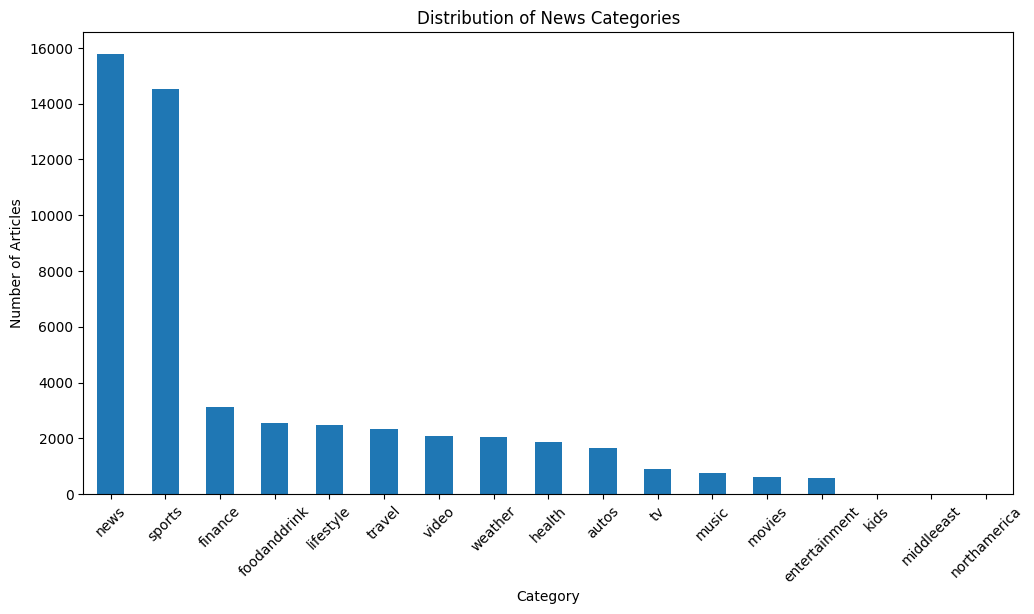

In [39]:
plt.figure(figsize=(12,6))

category_counts.plot(kind="bar")

plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)

plt.show()

In [40]:
news.isnull().sum()

news_id                 0
category                0
subcategory             0
title                   0
abstract             2666
url                     0
title_entities          3
abstract_entities       4
dtype: int64

In [41]:
behaviors.isnull().sum()

impression_id       0
user_id             0
time                0
history          3238
impressions         0
dtype: int64

In [42]:
news[["category", "title"]].sample(10, random_state=42)

,category,title
36810,news,The 3 best Greek spots in Aurora
24447,sports,Officials investigating stabbing death of Alex...
23187,finance,"SmileDirectClub tanks on California bill, brin..."
22077,travel,The world's 50 most reliable airlines
32260,sports,High school football: Breaking down the Class ...
13909,news,"Car trailer hauling 5 vehicles, including Pors..."
14233,news,"At a UFC event, Trump receives second round of..."
5567,news,They Crossed an Ocean to Butcher Pigs. It Was ...
20815,sports,LeBron's controversial comments 'furthers his ...
9911,news,Mom gets to hear son's heartbeat again 5 years...


In [43]:
print(news.shape)
print(behaviors.shape)

(51282, 8)
(156965, 5)


In [44]:
news["category"].value_counts()

category
news             15774
sports           14510
finance           3107
foodanddrink      2551
lifestyle         2479
travel            2350
video             2068
weather           2048
health            1885
autos             1639
tv                 889
music              769
movies             606
entertainment      587
kids                17
middleeast           2
northamerica         1
Name: count, dtype: int64

In [45]:
news.head()

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [46]:
behaviors["user_id"].nunique()

50000

In [47]:
behaviors["history"].head()

0    N55189 N42782 N34694 N45794 N18445 N63302 N104...
1    N31739 N6072 N63045 N23979 N35656 N43353 N8129...
2    N10732 N25792 N7563 N21087 N41087 N5445 N60384...
3    N45729 N2203 N871 N53880 N41375 N43142 N33013 ...
4                          N10078 N56514 N14904 N33740
Name: history, dtype: object

In [48]:
behaviors["impressions"].head()

0                                    N55689-1 N35729-0
1    N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2    N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3                  N35729-0 N33632-0 N49685-1 N27581-0
4    N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...
Name: impressions, dtype: object

In [49]:
history_lengths = (
    behaviors["history"]
    .fillna("")
    .apply(lambda x: len(x.split()) if x else 0)
)

history_lengths.describe()

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history, dtype: float64

In [50]:
impression_lengths = (
    behaviors["impressions"]
    .str.split()
    .apply(len)
)

impression_lengths.describe()

count    156965.000000
mean         37.227688
std          38.594148
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impressions, dtype: float64

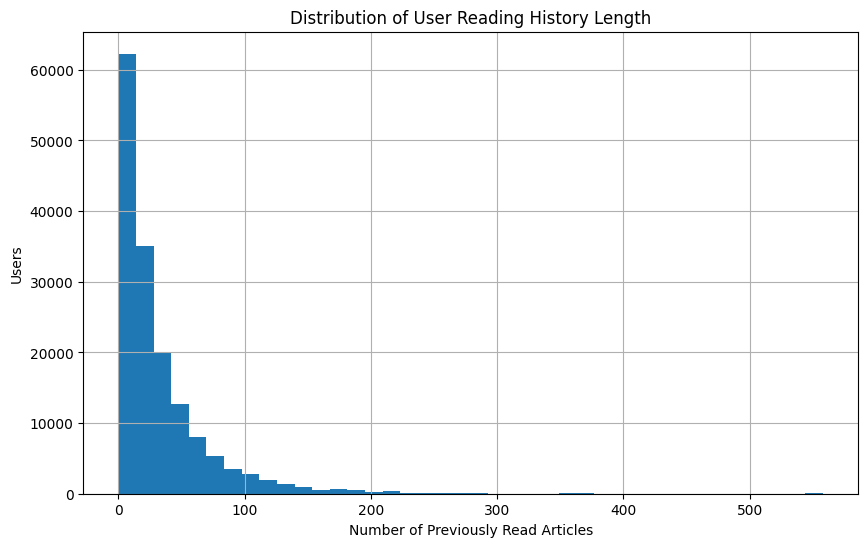

In [51]:
plt.figure(figsize=(10, 6))

history_lengths.hist(bins=40)

plt.title("Distribution of User Reading History Length")
plt.xlabel("Number of Previously Read Articles")
plt.ylabel("Users")

plt.show()

Dataset Overview

In [52]:
print("=" * 60)
print("MIND DATASET OVERVIEW")
print("=" * 60)

print(f"News articles      : {len(news):,}")
print(f"User sessions      : {len(behaviors):,}")
print(f"Unique users       : {behaviors.user_id.nunique():,}")
print(f"Categories         : {news.category.nunique()}")
print(f"Subcategories      : {news.subcategory.nunique()}")

MIND DATASET OVERVIEW
News articles      : 51,282
User sessions      : 156,965
Unique users       : 50,000
Categories         : 17
Subcategories      : 264


News Analysis
Category Distribution

In [53]:
category_counts = (
    news["category"]
    .value_counts()
    .sort_values(ascending=False)
)

category_counts

category
news             15774
sports           14510
finance           3107
foodanddrink      2551
lifestyle         2479
travel            2350
video             2068
weather           2048
health            1885
autos             1639
tv                 889
music              769
movies             606
entertainment      587
kids                17
middleeast           2
northamerica         1
Name: count, dtype: int64

Chart

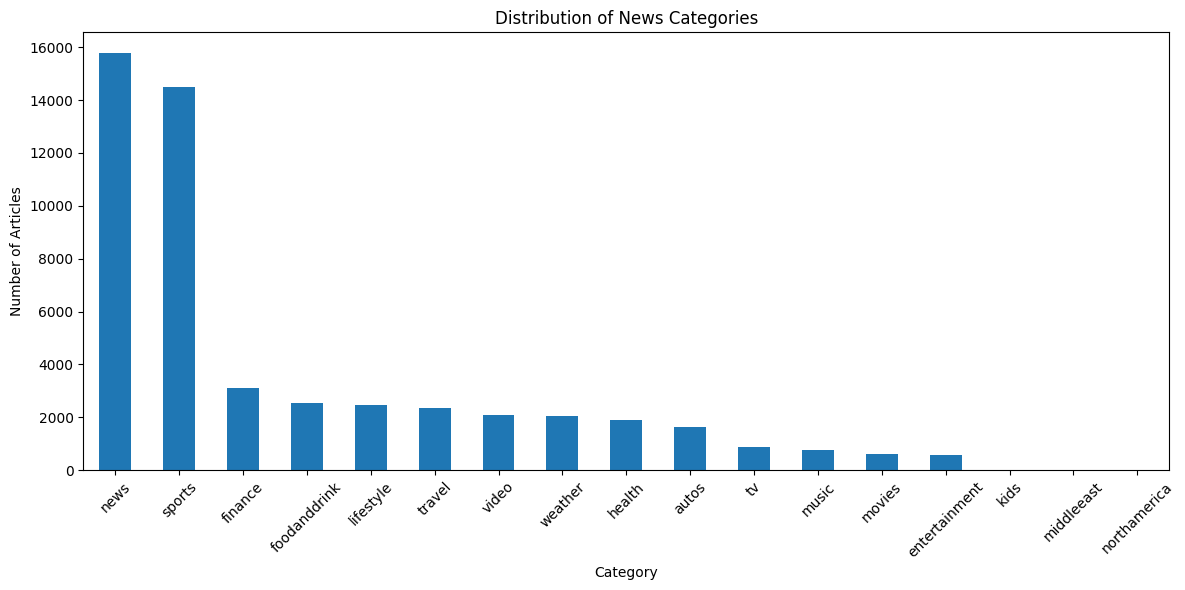

In [54]:
plt.figure(figsize=(12,6))

category_counts.plot(kind="bar")

plt.title("Distribution of News Categories")

plt.xlabel("Category")

plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Top Subcategories

In [55]:
news["subcategory"].value_counts().head(20)

subcategory
newsus                      6564
football_nfl                5420
newspolitics                2826
newscrime                   2254
weathertopstories           2047
newsworld                   1720
football_ncaa               1665
baseball_mlb                1661
basketball_nba              1555
newsscienceandtechnology    1210
news                        1185
newstrends                  1176
more_sports                 1065
travelarticle               1042
travelnews                   902
lifestylebuzz                894
autosnews                    837
basketball_ncaa              774
financenews                  697
finance-real-estate          584
Name: count, dtype: int64

Reader Behavior 

History Length

In [56]:
behaviors["history_length"] = (
    behaviors["history"]
    .fillna("")
    .apply(lambda x: len(x.split()) if x else 0)
)

In [57]:
behaviors["history_length"].describe()

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_length, dtype: float64

Distribution

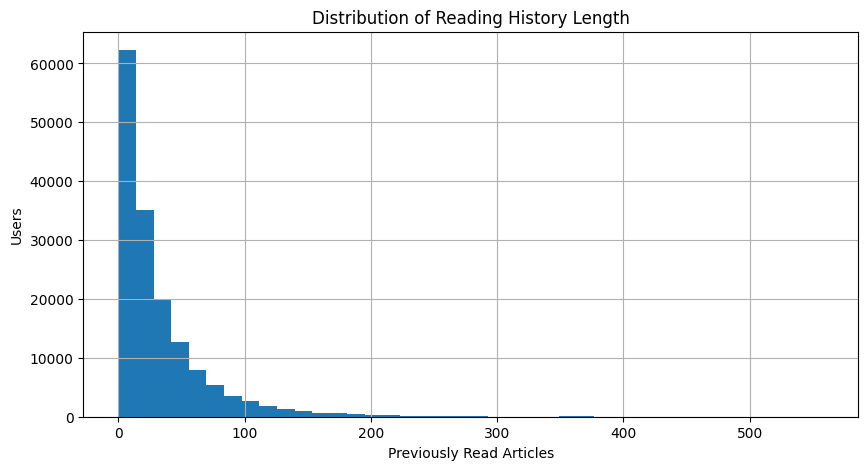

In [58]:
plt.figure(figsize=(10,5))

behaviors["history_length"].hist(bins=40)

plt.title("Distribution of Reading History Length")

plt.xlabel("Previously Read Articles")

plt.ylabel("Users")

plt.show()

Impression Length

In [59]:
behaviors["impression_length"] = (
    behaviors["impressions"]
    .str.split()
    .apply(len)
)

In [60]:
behaviors["impression_length"].describe()

count    156965.000000
mean         37.227688
std          38.594148
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impression_length, dtype: float64

Plot

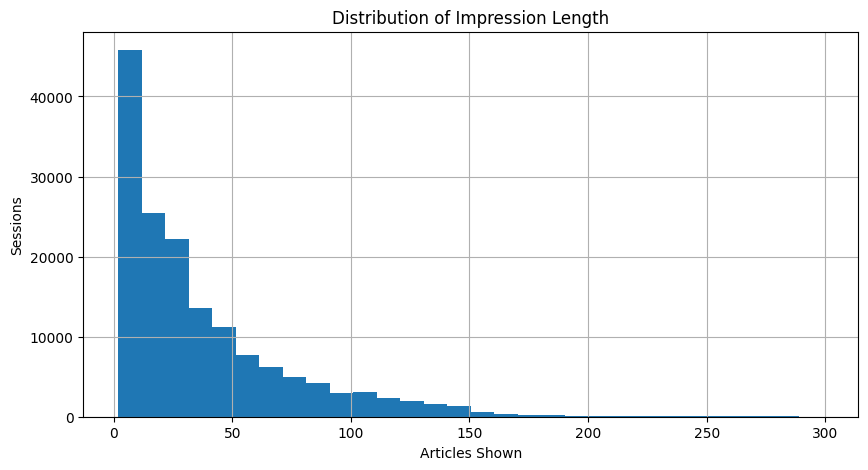

In [61]:
plt.figure(figsize=(10,5))

behaviors["impression_length"].hist(bins=30)

plt.title("Distribution of Impression Length")

plt.xlabel("Articles Shown")

plt.ylabel("Sessions")

plt.show()

Editorial Analytics

Articles per category

In [62]:
editorial = (
    news.groupby("category")
        .size()
        .sort_values(ascending=False)
        .reset_index(name="articles")
)

editorial

,category,articles
0,news,15774
1,sports,14510
2,finance,3107
3,foodanddrink,2551
4,lifestyle,2479
5,travel,2350
6,video,2068
7,weather,2048
8,health,1885
9,autos,1639


Coverage Percentage

In [63]:
editorial["coverage_pct"] = (
    editorial["articles"] /
    editorial["articles"].sum()
    *100
)

editorial

,category,articles,coverage_pct
0,news,15774,30.759331
1,sports,14510,28.294528
2,finance,3107,6.058656
3,foodanddrink,2551,4.974455
4,lifestyle,2479,4.834055
5,travel,2350,4.582505
6,video,2068,4.032604
7,weather,2048,3.993604
8,health,1885,3.675754
9,autos,1639,3.196053


The dataset contains over 51,000 articles across 16 categories.
The News and Sports sections account for more than half of all articles.
Reader histories vary substantially, indicating that personalization could improve content discovery.
The distribution of articles is highly imbalanced, suggesting that a popularity-based recommender may over-represent dominant categories.
Future recommendation models should balance relevance with content diversity.